In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('spotify_tracks.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped unnamed index column")

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'spotify_tracks.csv'

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

rows_before = len(df)
df = df.dropna(subset=['artists', 'track_name', 'track_genre'])
rows_after = len(df)

print(f"\nRows removed: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after}")

Missing values per column:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Rows removed: 1
Rows remaining: 113999


In [ ]:
dup_id = df.duplicated(subset='track_id').sum()
dup_exact = df.duplicated().sum()

print(f"Duplicate track_id entries: {dup_id}")
print(f"Exact duplicate rows: {dup_exact}")
print("Note: track_id duplicates may represent the same song appearing in multiple genres or playlists.")
print("Therefore, we only remove exact duplicate rows to preserve valid data.")

rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)

print(f"\nRows removed: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after}")


Duplicate track_id entries: 24259
Exact duplicate rows: 450
Note: track_id duplicates may represent the same song appearing in multiple genres or playlists.
Therefore, we only remove exact duplicate rows to preserve valid data.

Rows removed: 450
Rows remaining: 113549


In [ ]:
df['duration_minutes'] = (df['duration_ms'] / 60000).round(2)
df = df.drop(columns=['duration_ms'])

df['explicit'] = df['explicit'].astype(bool)

print("New column: duration_minutes")
print(df[['duration_minutes', 'explicit']].head())
print("\nexplicit value counts:", df['explicit'].value_counts())

New column: duration_minutes
   duration_minutes  explicit
0              3.84     False
1              2.49     False
2              3.51     False
3              3.37     False
4              3.31     False

explicit value counts: explicit
False    103831
True       9718
Name: count, dtype: int64


In [ ]:
df['is_zero_popularity'] = df['popularity'] == 0

zero_count = df['is_zero_popularity'].sum()
total = len(df)
print(f"Zero-popularity tracks: {zero_count} ({100*zero_count/total:.1f}% of dataset)")
print(df['popularity'].describe())

rows_before = len(df)
df = df[df['duration_minutes'] <= 15]
print(f"\nDuration outliers removed: {rows_before - len(df)}")
print(f"Rows remaining: {len(df)}")

Zero-popularity tracks: 15843 (14.0% of dataset)
count    113549.000000
mean         33.324433
std          22.283855
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

Duration outliers removed: 149
Rows remaining: 113400


Unique genres before: 114
Unique genres after: 114


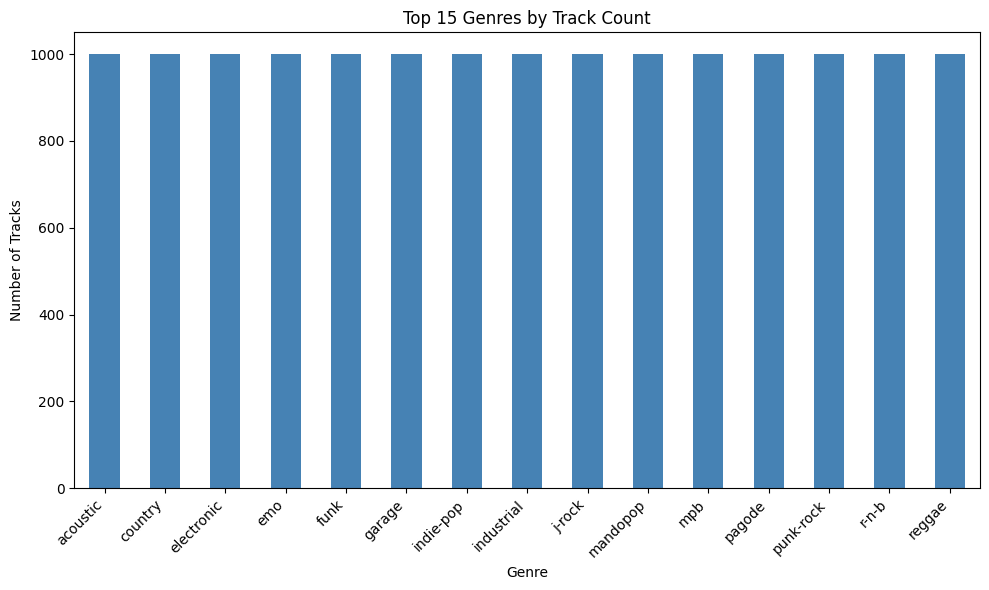

In [ ]:
print(f"Unique genres before: {df['track_genre'].nunique()}")

df['track_genre'] = df['track_genre'].str.strip().str.lower()

print(f"Unique genres after: {df['track_genre'].nunique()}")

top_genres = df['track_genre'].value_counts().head(15)
plt.figure(figsize=(10,6))
top_genres.plot(kind='bar', color='steelblue')
plt.title('Top 15 Genres by Track Count')
plt.xlabel('Genre')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('genre_distribution.png')
plt.show()

In [ ]:
df.to_csv('spotify_cleaned.csv', index=False)
print(f"Cleaned dataset saved as spotify_cleaned.csv")
print(f"Dataset shape after cleaning: {df.shape}")
print(f"The cleaned dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns, suitable for large-scale analysis.")

Cleaned dataset saved as spotify_cleaned.csv
Dataset shape after cleaning: (113400, 21)
The cleaned dataset contains 113,400 rows and 21 columns, suitable for large-scale analysis.
